# Brain tumor 2D segmentation with MONAI

This notebook performs multi-label segmentation of brain tumors using the BraTS2020 dataset stored locally as pre-processed 2D HDF5 slices.

Features:
1. Custom PyTorch Dataset for loading H5 slice data.
1. Patient-level train/validation split (80/20).
1. Data augmentation with random flips and intensity transforms.
1. 2D UNet model with Dice loss and Mean Dice metric.
1. Deterministic training for reproducibility.

**Tumor sub-regions:**
- **TC** (Tumor Core): union of GD-enhancing tumor and necrotic/non-enhancing core
- **WT** (Whole Tumor): union of TC and peritumoral edema
- **ET** (Enhancing Tumor): GD-enhancing tumor only

![image](../figures/brats_tasks.png)

## Setup environment

In [1]:
%matplotlib inline

## Setup imports

In [2]:
import os
import sys
import time
import glob
import matplotlib.pyplot as plt
import numpy as np
import h5py
from sklearn.model_selection import train_test_split

from monai.config import print_config
from monai.data import DataLoader, decollate_batch
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.networks.nets import UNet
from monai.transforms import (
    Activations,
    AsDiscrete,
    Compose,
    RandFlipd,
    RandScaleIntensityd,
    RandShiftIntensityd,
    NormalizeIntensityd,
    EnsureTyped,
)
from monai.utils import set_determinism

import torch

# Ensure src/ is importable so spawned workers can find BraTSH5Dataset
_src_dir = os.path.normpath(os.path.join(os.getcwd(), ".."))
if _src_dir not in sys.path:
    sys.path.insert(0, _src_dir)

from datasets import BraTSH5Dataset

print_config()

MONAI version: 1.5.2
Numpy version: 2.4.2
Pytorch version: 2.10.0
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /Users/<username>/cogito/cancervision/.venv/lib/python3.13/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.4.0
scikit-image version: NOT INSTALLED or UNKNOWN VERSION.
scipy version: 1.17.1
Pillow version: 12.1.1
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.25.0
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.2.2
pandas version: NOT INSTALLED or UNKNOWN VERSION.
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: 

## Setup data directory

Point to the local BraTS2020 dataset in the `res/` folder. The dataset contains pre-processed 2D slices in HDF5 format with:
- `image`: (240, 240, 4) - 4 MRI modalities (FLAIR, T1w, T1gd, T2w)
- `mask`: (240, 240, 3) - 3 binary channels (TC, WT, ET)

In [3]:
data_dir = os.path.join(os.getcwd(), "..", "..", "res", "data", "archive", "BraTS2020_training_data", "content", "data")
data_dir = os.path.normpath(data_dir)
print(f"Data directory: {data_dir}")
print(f"Exists: {os.path.isdir(data_dir)}")

h5_files = sorted(glob.glob(os.path.join(data_dir, "*.h5")))
print(f"Total H5 files: {len(h5_files)}")

Data directory: /Users/heap/cogito/cancervision/res/data/archive/BraTS2020_training_data/content/data
Exists: True
Total H5 files: 57195


## Set deterministic training for reproducibility

In [4]:
set_determinism(seed=0)

## BraTSH5Dataset

The `BraTSH5Dataset` class is imported from `src/datasets/brats_h5.py`. It is defined in an external module so that macOS `spawn`-based multiprocessing workers can pickle and import it correctly.

Each H5 file contains a pre-processed 2D slice with 4-channel image and 3-channel binary mask (TC, WT, ET).

## Setup transforms for training and validation

Since the data is already pre-processed 2D slices with channel-first format, we only need augmentation transforms for training.

In [5]:
train_transform = Compose(
    [
        EnsureTyped(keys=["image", "label"]),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
        RandScaleIntensityd(keys="image", factors=0.1, prob=1.0),
        RandShiftIntensityd(keys="image", offsets=0.1, prob=1.0),
    ]
)
val_transform = Compose(
    [
        EnsureTyped(keys=["image", "label"]),
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    ]
)

## Load local BraTS2020 dataset and split into train/validation

Split by volume ID so that slices from the same patient don't appear in both train and validation sets.

In [6]:
# Group files by volume ID for patient-level split
from collections import defaultdict
import multiprocessing as mp

# Use 'spawn' explicitly on macOS for safe multiprocessing
mp.set_start_method("spawn", force=True)

volume_files = defaultdict(list)
for fp in h5_files:
    fname = os.path.basename(fp)
    vol_id = int(fname.split("_")[1])
    volume_files[vol_id].append(fp)

volume_ids = sorted(volume_files.keys())
train_vols, val_vols = train_test_split(volume_ids, test_size=0.2, random_state=42)

train_files = [fp for vid in train_vols for fp in volume_files[vid]]
val_files = [fp for vid in val_vols for fp in volume_files[vid]]

print(f"Train volumes: {len(train_vols)}, Val volumes: {len(val_vols)}")
print(f"Train slices: {len(train_files)}, Val slices: {len(val_files)}")

train_ds = BraTSH5Dataset(train_files, transform=train_transform)
val_ds = BraTSH5Dataset(val_files, transform=val_transform)

num_workers = min(4, mp.cpu_count() or 1)
print(f"DataLoader num_workers: {num_workers}")

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=num_workers, persistent_workers=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=num_workers, persistent_workers=True)

Train volumes: 295, Val volumes: 74
Train slices: 45725, Val slices: 11470
DataLoader num_workers: 4


## Check data shape and visualize

image shape: torch.Size([4, 240, 240])
label shape: torch.Size([3, 240, 240])


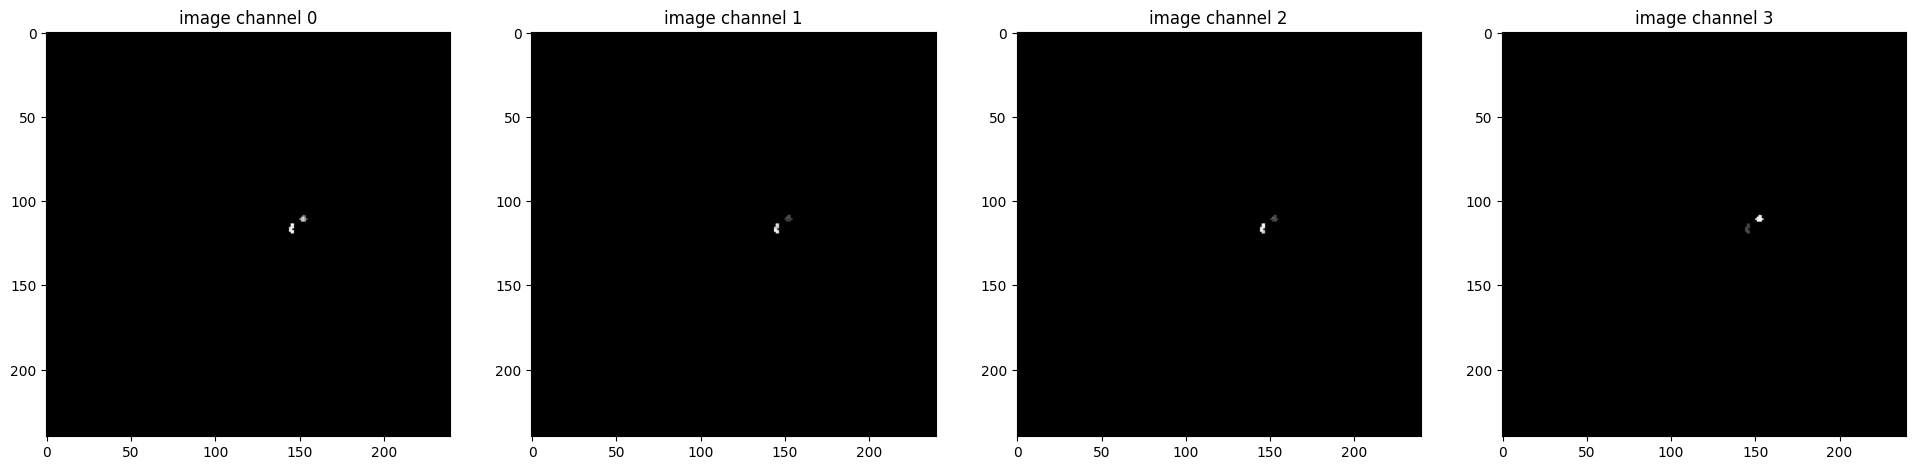

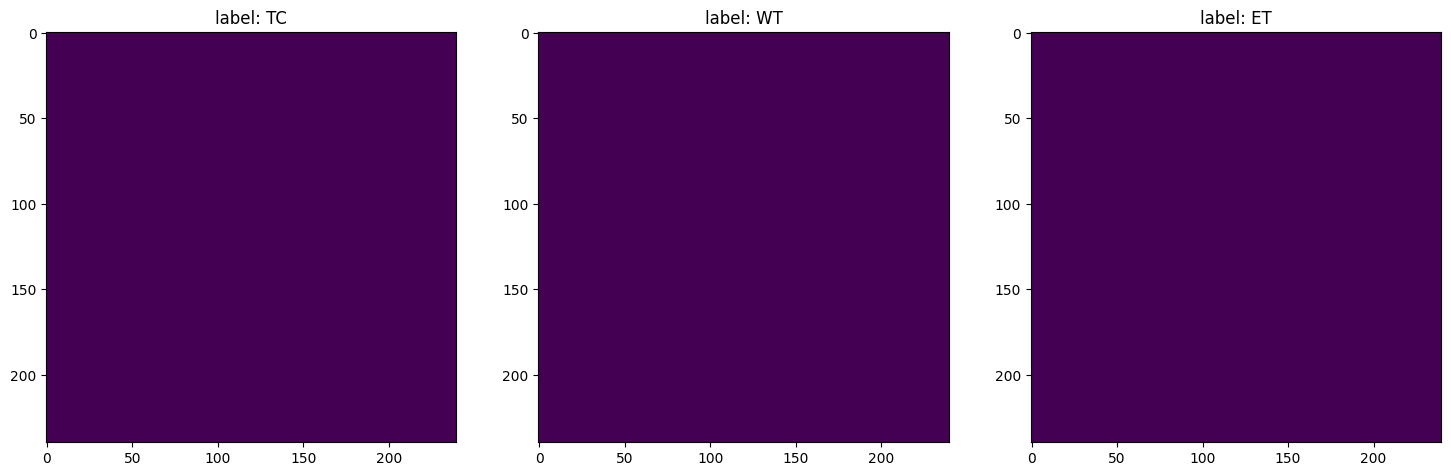

In [7]:
# Pick one sample from validation set to visualize
val_sample = val_ds[len(val_ds) // 2]
print(f"image shape: {val_sample['image'].shape}")
print(f"label shape: {val_sample['label'].shape}")

plt.figure("image", (24, 6))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.title(f"image channel {i}")
    plt.imshow(val_sample["image"][i].detach().cpu(), cmap="gray")
plt.show()

plt.figure("label", (18, 6))
channel_names = ["TC", "WT", "ET"]
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.title(f"label: {channel_names[i]}")
    plt.imshow(val_sample["label"][i].detach().cpu())
plt.show()

## Create UNet, DiceLoss and Adam optimizer

In [8]:
max_epochs = 10
val_interval = 1

# Select device: MPS (Apple Silicon), CUDA, or CPU
if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# 2D UNet: (4, 240, 240) input -> (3, 240, 240) output
model = UNet(
    spatial_dims=2,
    in_channels=4,
    out_channels=3,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    dropout=0.2,
).to(device)

loss_function = DiceLoss(smooth_nr=0, smooth_dr=1e-5, squared_pred=True, to_onehot_y=False, sigmoid=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-4, weight_decay=1e-5)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

dice_metric = DiceMetric(include_background=True, reduction="mean")
dice_metric_batch = DiceMetric(include_background=True, reduction="mean_batch")

post_trans = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])

Using device: mps


## Execute a typical PyTorch training process

In [9]:
best_metric = -1
best_metric_epoch = -1
best_metrics_epochs_and_time = [[], [], []]
epoch_loss_values = []
metric_values = []
metric_values_tc = []
metric_values_wt = []
metric_values_et = []

save_dir = os.path.join(os.getcwd(), "..", "..", "res", "models")
os.makedirs(save_dir, exist_ok=True)

total_start = time.time()
for epoch in range(max_epochs):
    epoch_start = time.time()
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step_start = time.time()
        step += 1
        inputs, labels = (
            batch_data["image"].to(device),
            batch_data["label"].to(device),
        )
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        if step % 50 == 0:
            print(
                f"{step}/{len(train_ds) // train_loader.batch_size}"
                f", train_loss: {loss.item():.4f}"
                f", step time: {(time.time() - step_start):.4f}"
            )
    lr_scheduler.step()
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels = (
                    val_data["image"].to(device),
                    val_data["label"].to(device),
                )
                val_outputs = model(val_inputs)
                val_outputs = [post_trans(i) for i in decollate_batch(val_outputs)]
                dice_metric(y_pred=val_outputs, y=val_labels)
                dice_metric_batch(y_pred=val_outputs, y=val_labels)

            metric = dice_metric.aggregate().item()
            metric_values.append(metric)
            metric_batch = dice_metric_batch.aggregate()
            metric_tc = metric_batch[0].item()
            metric_values_tc.append(metric_tc)
            metric_wt = metric_batch[1].item()
            metric_values_wt.append(metric_wt)
            metric_et = metric_batch[2].item()
            metric_values_et.append(metric_et)
            dice_metric.reset()
            dice_metric_batch.reset()

            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                best_metrics_epochs_and_time[0].append(best_metric)
                best_metrics_epochs_and_time[1].append(best_metric_epoch)
                best_metrics_epochs_and_time[2].append(time.time() - total_start)
                torch.save(
                    model.state_dict(),
                    os.path.join(save_dir, "best_metric_model.pth"),
                )
                print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current mean dice: {metric:.4f}"
                f" tc: {metric_tc:.4f} wt: {metric_wt:.4f} et: {metric_et:.4f}"
                f"\nbest mean dice: {best_metric:.4f}"
                f" at epoch: {best_metric_epoch}"
            )
    print(f"time consuming of epoch {epoch + 1} is: {(time.time() - epoch_start):.4f}")
total_time = time.time() - total_start

----------
epoch 1/10
50/2857, train_loss: 0.9796, step time: 0.0346
100/2857, train_loss: 0.9775, step time: 0.0357
150/2857, train_loss: 0.9738, step time: 0.0347
200/2857, train_loss: 0.9677, step time: 0.0352
250/2857, train_loss: 0.9869, step time: 0.0346
300/2857, train_loss: 0.9808, step time: 0.0364
350/2857, train_loss: 0.9761, step time: 0.0347
400/2857, train_loss: 0.9715, step time: 0.0360
450/2857, train_loss: 0.9812, step time: 0.0347
500/2857, train_loss: 0.9649, step time: 0.0352
550/2857, train_loss: 0.9759, step time: 0.0344
600/2857, train_loss: 0.9935, step time: 0.0352
650/2857, train_loss: 0.9619, step time: 0.0347
700/2857, train_loss: 0.9792, step time: 0.0351
750/2857, train_loss: 0.9668, step time: 0.0347
800/2857, train_loss: 0.9845, step time: 0.0352
850/2857, train_loss: 0.9726, step time: 0.0353
900/2857, train_loss: 0.9748, step time: 0.0354
950/2857, train_loss: 0.9912, step time: 0.0348
1000/2857, train_loss: 0.9573, step time: 0.0350
1050/2857, train_l

RuntimeError: Shared memory manager connection has timed out
Exception raised from recv at /Users/runner/work/pytorch/pytorch/pytorch/torch/lib/libshm/../../../torch/lib/libshm/socket.h:67 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__1::basic_string<char, std::__1::char_traits<char>, std::__1::allocator<char>>) + 52 (0x114f61988 in libc10.dylib)
frame #1: c10::detail::torchCheckFail(char const*, char const*, unsigned int, char const*) + 192 (0x114f5e734 in libc10.dylib)
frame #2: Socket::recv(void*, unsigned long) + 340 (0x11414b034 in libshm.dylib)
frame #3: THManagedMapAllocatorInit::THManagedMapAllocatorInit(char const*, char const*) + 1436 (0x114147dc0 in libshm.dylib)
frame #4: THManagedMapAllocator::makeDataPtr(char const*, char const*, int, unsigned long) + 76 (0x1141484f8 in libshm.dylib)
frame #5: THPStorage_newSharedFilename(_object*, _object*) + 272 (0x116f6ab44 in libtorch_python.dylib)
<omitting python frames>
frame #37: start + 7184 (0

In [ ]:
print(f"train completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}, total time: {total_time:.1f}s.")

## Plot the loss and metric

In [ ]:
plt.figure("train", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel("epoch")
plt.plot(x, y, color="red")
plt.subplot(1, 2, 2)
plt.title("Val Mean Dice")
x = [val_interval * (i + 1) for i in range(len(metric_values))]
y = metric_values
plt.xlabel("epoch")
plt.plot(x, y, color="green")
plt.show()

plt.figure("train", (18, 6))
plt.subplot(1, 3, 1)
plt.title("Val Mean Dice TC")
x = [val_interval * (i + 1) for i in range(len(metric_values_tc))]
y = metric_values_tc
plt.xlabel("epoch")
plt.plot(x, y, color="blue")
plt.subplot(1, 3, 2)
plt.title("Val Mean Dice WT")
x = [val_interval * (i + 1) for i in range(len(metric_values_wt))]
y = metric_values_wt
plt.xlabel("epoch")
plt.plot(x, y, color="brown")
plt.subplot(1, 3, 3)
plt.title("Val Mean Dice ET")
x = [val_interval * (i + 1) for i in range(len(metric_values_et))]
y = metric_values_et
plt.xlabel("epoch")
plt.plot(x, y, color="purple")
plt.show()

## Check best pytorch model output with the input image and label

In [ ]:
model.load_state_dict(torch.load(os.path.join(save_dir, "best_metric_model.pth"), weights_only=True))
model.eval()
with torch.no_grad():
    # select one sample to evaluate and visualize
    sample_idx = len(val_ds) // 2
    val_input = val_ds[sample_idx]["image"].unsqueeze(0).to(device)
    val_output = model(val_input)
    val_output = post_trans(val_output[0])

    plt.figure("image", (24, 6))
    for i in range(4):
        plt.subplot(1, 4, i + 1)
        plt.title(f"image channel {i}")
        plt.imshow(val_ds[sample_idx]["image"][i].detach().cpu(), cmap="gray")
    plt.show()

    plt.figure("label", (18, 6))
    channel_names = ["TC", "WT", "ET"]
    for i in range(3):
        plt.subplot(1, 3, i + 1)
        plt.title(f"label: {channel_names[i]}")
        plt.imshow(val_ds[sample_idx]["label"][i].detach().cpu())
    plt.show()

    plt.figure("output", (18, 6))
    for i in range(3):
        plt.subplot(1, 3, i + 1)
        plt.title(f"output: {channel_names[i]}")
        plt.imshow(val_output[i].detach().cpu())
    plt.show()

## Final evaluation on validation set

In [ ]:
model.load_state_dict(torch.load(os.path.join(save_dir, "best_metric_model.pth"), weights_only=True))
model.eval()

dice_metric.reset()
dice_metric_batch.reset()

with torch.no_grad():
    for val_data in val_loader:
        val_inputs = val_data["image"].to(device)
        val_labels = val_data["label"].to(device)
        val_outputs = model(val_inputs)
        val_outputs = [post_trans(i) for i in decollate_batch(val_outputs)]
        dice_metric(y_pred=val_outputs, y=val_labels)
        dice_metric_batch(y_pred=val_outputs, y=val_labels)

    metric_org = dice_metric.aggregate().item()
    metric_batch_org = dice_metric_batch.aggregate()
    dice_metric.reset()
    dice_metric_batch.reset()

metric_tc = metric_batch_org[0].item()
metric_wt = metric_batch_org[1].item()
metric_et = metric_batch_org[2].item()

print(f"Final validation mean Dice: {metric_org:.4f}")
print(f"  TC: {metric_tc:.4f}")
print(f"  WT: {metric_wt:.4f}")
print(f"  ET: {metric_et:.4f}")